## Training a model with a real dataset , to predict the price of a house per square unit area on the basis of the following feature.

$X_1$: House age (in years)  
$X_2$: Distance to the nearest MRT subway station (in meters)    
$X_3$: Number of convenience stores in the living circle on foot  
$Y$: House price of unit area

In [301]:
import numpy as np
from matplotlib import pyplot as plt

### Fetching the data from the csv file and not using the transcation , longitude and latitiude because it do not practically plays a good role in weight.

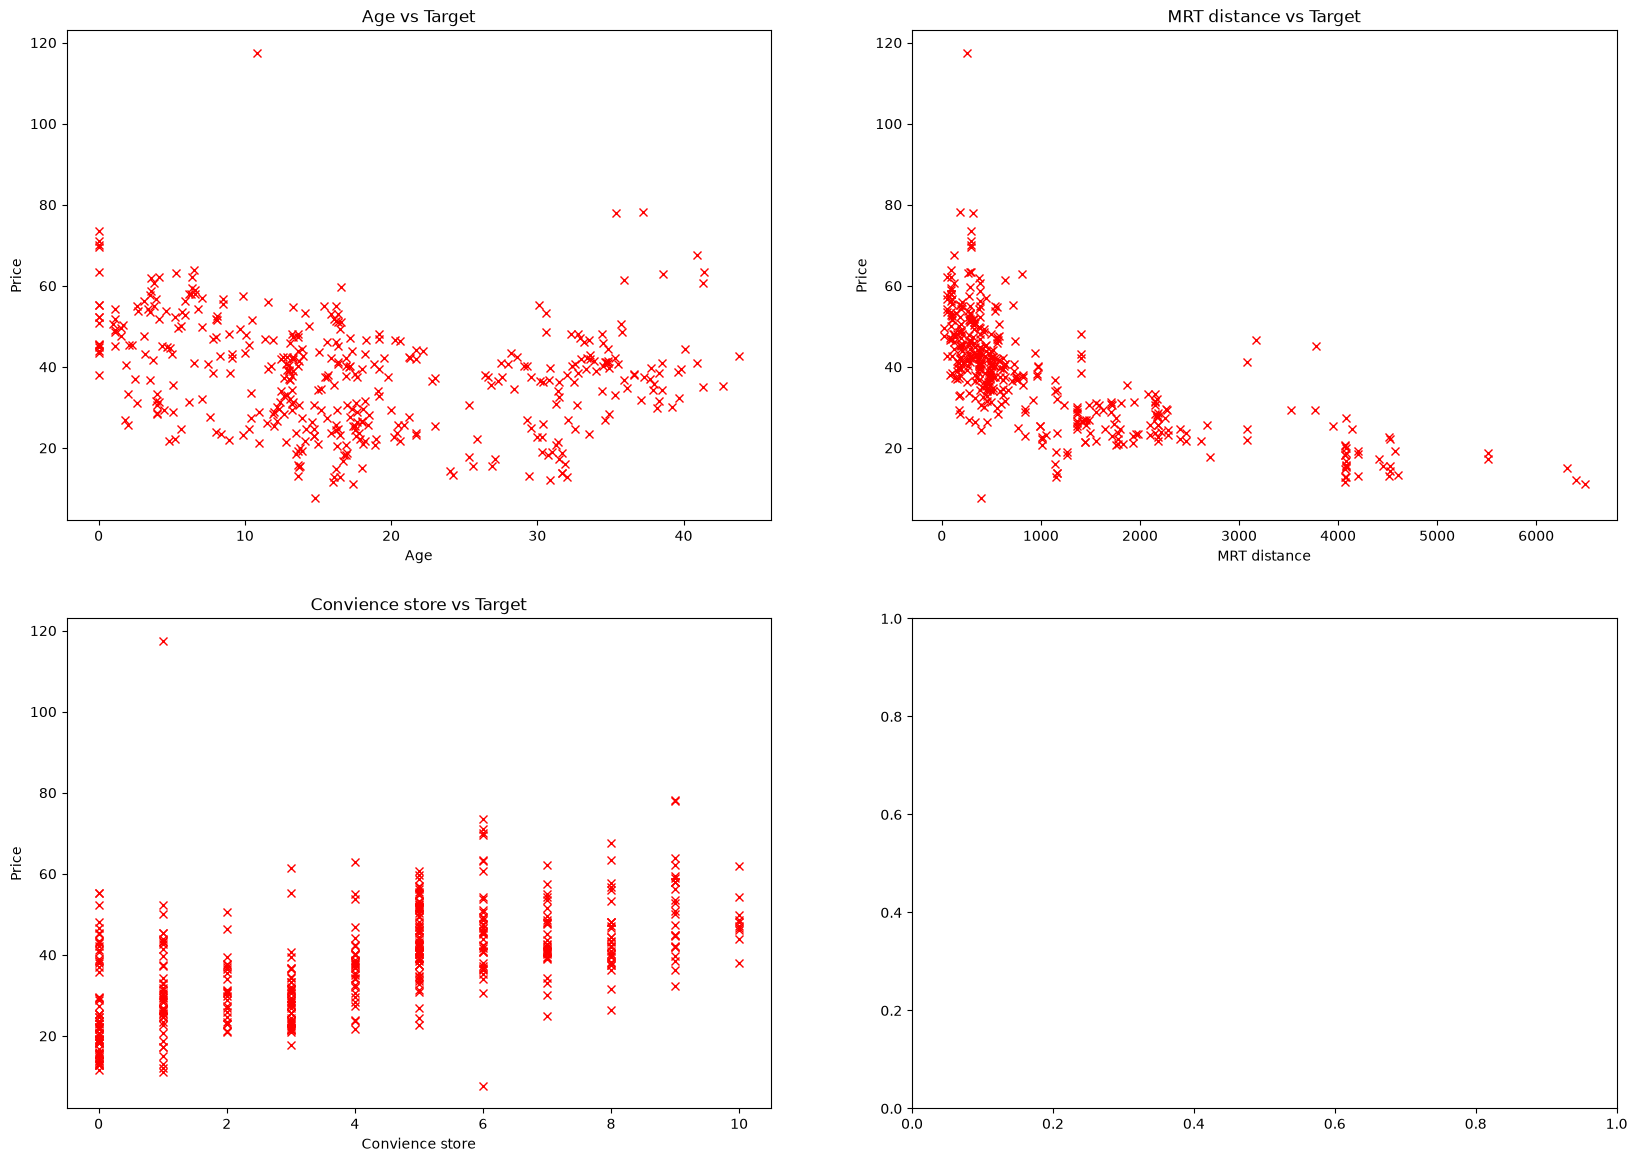

In [302]:
data = np.loadtxt('data.csv',delimiter=',', skiprows=1)
x_train = data[:, 1:4]
y_train = data[:, 6]

fig , ax = plt.subplots(2, 2, figsize=(20, 14))
ax[0,0].plot(x_train[:,0], y_train, 'rx')
ax[0,0].set_title('Age vs Target')
ax[0,0].set_xlabel('Age')
ax[0,0].set_ylabel('Price')
ax[0,1].plot(x_train[:,1], y_train, 'rx')
ax[0,1].set_title('MRT distance vs Target')
ax[0,1].set_xlabel('MRT distance')
ax[0,1].set_ylabel('Price')
ax[1,0].plot(x_train[:,2], y_train, 'rx')
ax[1,0].set_title('Convience store vs Target')
ax[1,0].set_xlabel('Convience store')
ax[1,0].set_ylabel('Price')
plt.show()


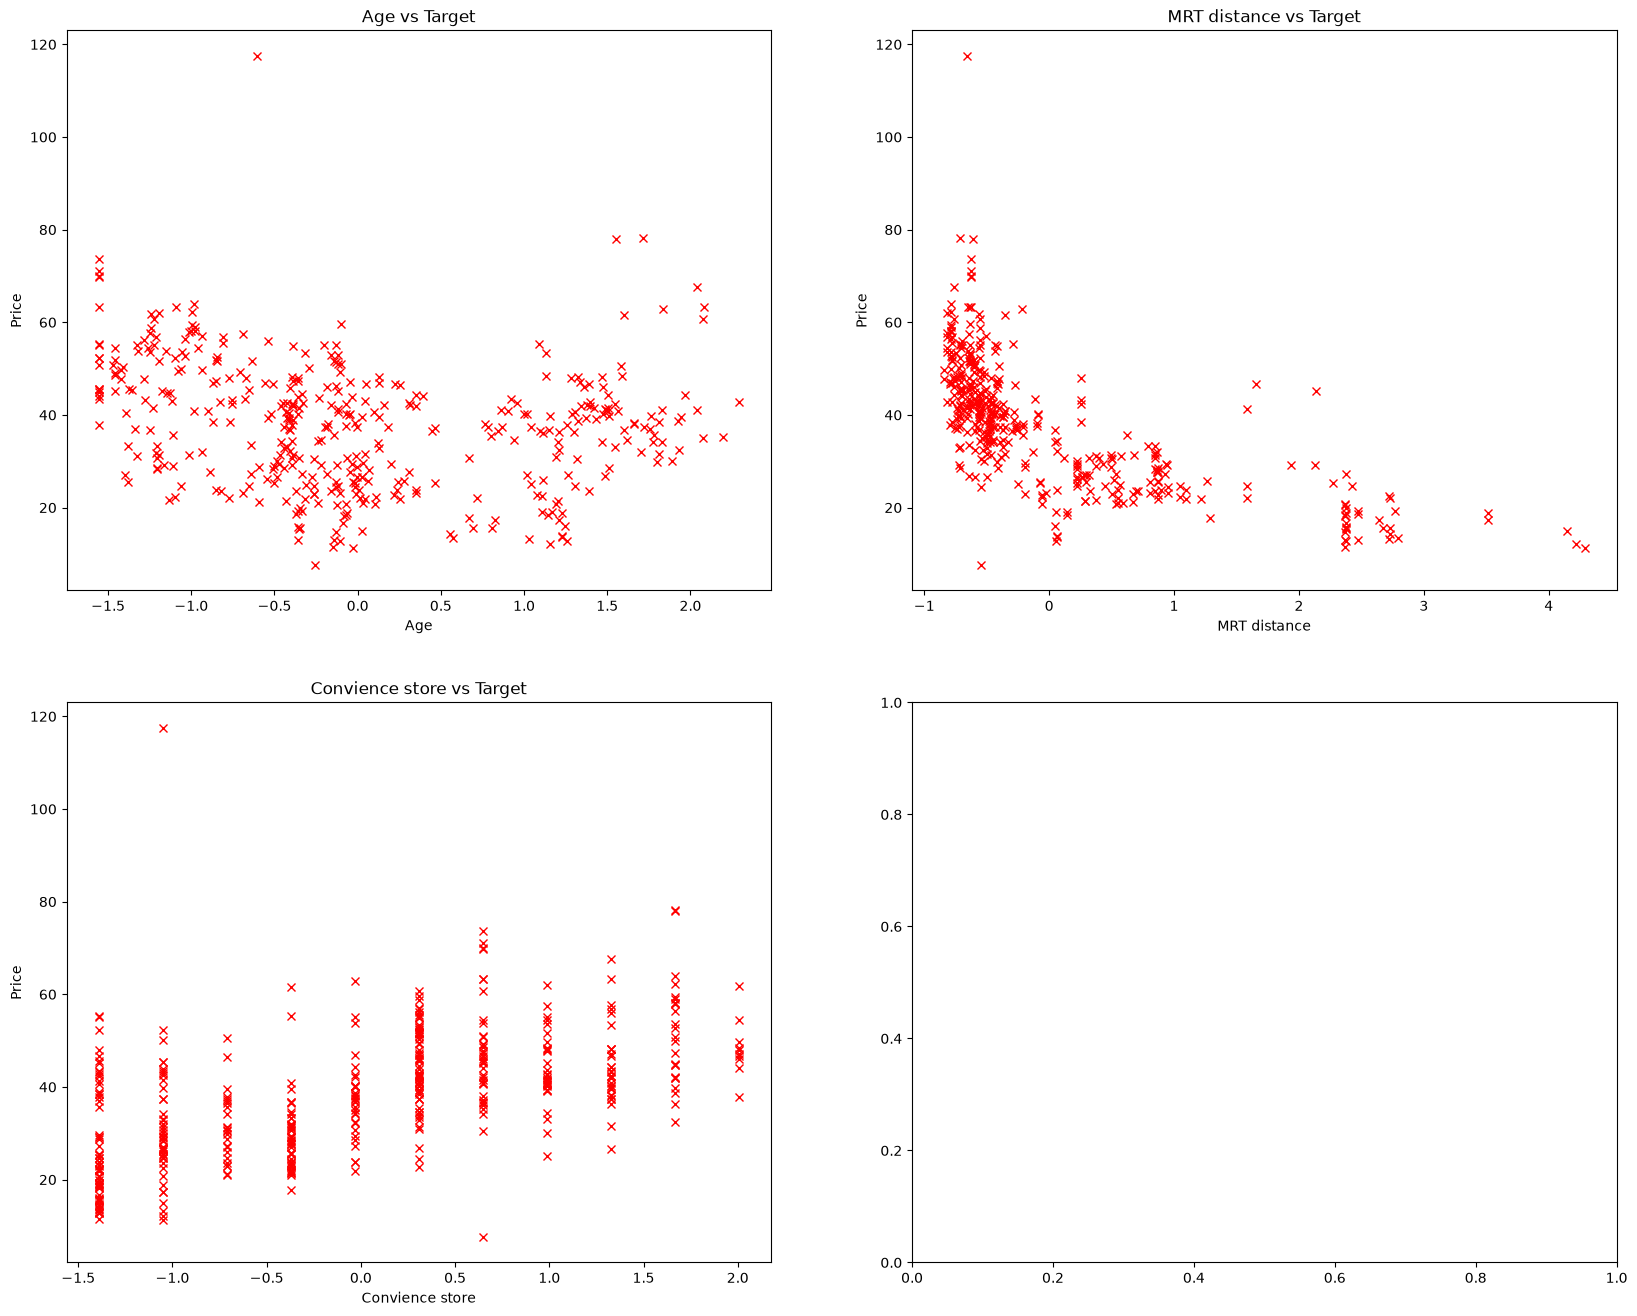

In [303]:
x_avg = np.mean(x_train, axis=0)
x_std = np.std(x_train, axis=0)
x_train = x_train - x_avg
x_train = x_train/x_std

fig , ax = plt.subplots(2, 2, figsize=(20, 16))
ax[0,0].plot(x_train[:,0], y_train, 'rx')
ax[0,0].set_title('Age vs Target')
ax[0,0].set_xlabel('Age')
ax[0,0].set_ylabel('Price')
ax[0,1].plot(x_train[:,1], y_train, 'rx')
ax[0,1].set_title('MRT distance vs Target')
ax[0,1].set_xlabel('MRT distance')
ax[0,1].set_ylabel('Price')
ax[1,0].plot(x_train[:,2], y_train, 'rx')
ax[1,0].set_title('Convience store vs Target')
ax[1,0].set_xlabel('Convience store')
ax[1,0].set_ylabel('Price')
plt.show()
# z score normalization

### Defining the inital value of prarmeters and learning rate.

In [304]:
w = np.zeros(x_train.shape[1])
b = 0
num_iters = 120
alpha = 0.1

## Defining the functions to calculate the predicted values.

In [ ]:
def compute_yhat(x,w=w,b=b):
    """
    f(x) = x.w + b
    """
    return np.dot(x,w) + b


In [306]:
def compute_cost(x,y, w=w , b=b):
    """
    J(w,b) = 1/2m*sum((f(x) - y)^2)
    """
    m = x.shape[0]
    yhat = compute_yhat(x,w,b)
    cost = np.square((yhat - y))
    cost = np.sum(cost)
    cost = cost/(2*m)
    return cost


In [ ]:
def implement_gradient_descent(x, y , w = w , b = b, alpha = alpha, num_iters = num_iters):
    """
    w = w - alpha*dj_dw
    b = b - alpha*dj_db 
    dj_dw = 1/m*sum((yhat - y)*x)
    """
    cost = np.array([compute_cost(x,y)])
    iterations = np.array([0])
    m = x.shape[0]
    for i in range(1, num_iters+1):
        yhat = np.dot(x,w) + b
        error = yhat - y
        dj_dw = np.dot(error , x) / m
        dj_db = np.sum(error) / m
        w = w - alpha*dj_dw
        b = b - alpha*dj_db
        if i%4 == 0:
            iterations = np.append(iterations, i)
            cost = np.append(cost , compute_cost(x,y,w,b))

    return w , b , cost , iterations


### Now plotting graph and predicating the value of a random data.

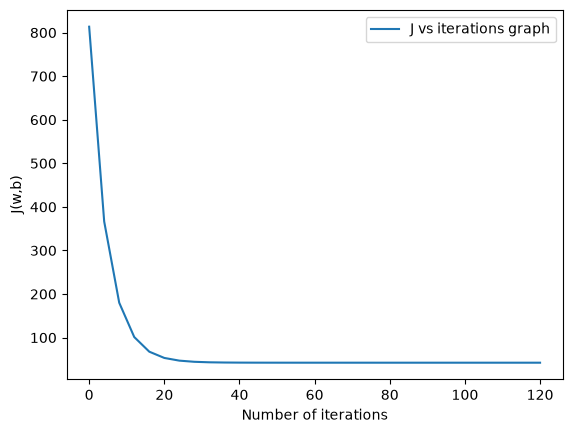

Predicted price of a 20 years old, 1650 m away from MRT ,and having 4 convienvce store near itself : $34.24 per unit area.


In [309]:
w , b, cost, iterations = implement_gradient_descent(x_train, y_train)
yhat = compute_yhat(x_train, w , b)
plt.plot(iterations, cost, label="J vs iterations graph")
plt.xlabel("Number of iterations")
plt.ylabel("J(w,b)")
plt.legend()
plt.show()

x = np.array([20, 1650, 4]) - x_avg
x = x/x_std
print(f"Predicted price of a 20 years old, 1650 m away from MRT ,and having 4 convienvce store near itself : ${compute_yhat(x, w, b):.2f} per unit area." )


# Plotting graph of each feature vs target and the model .

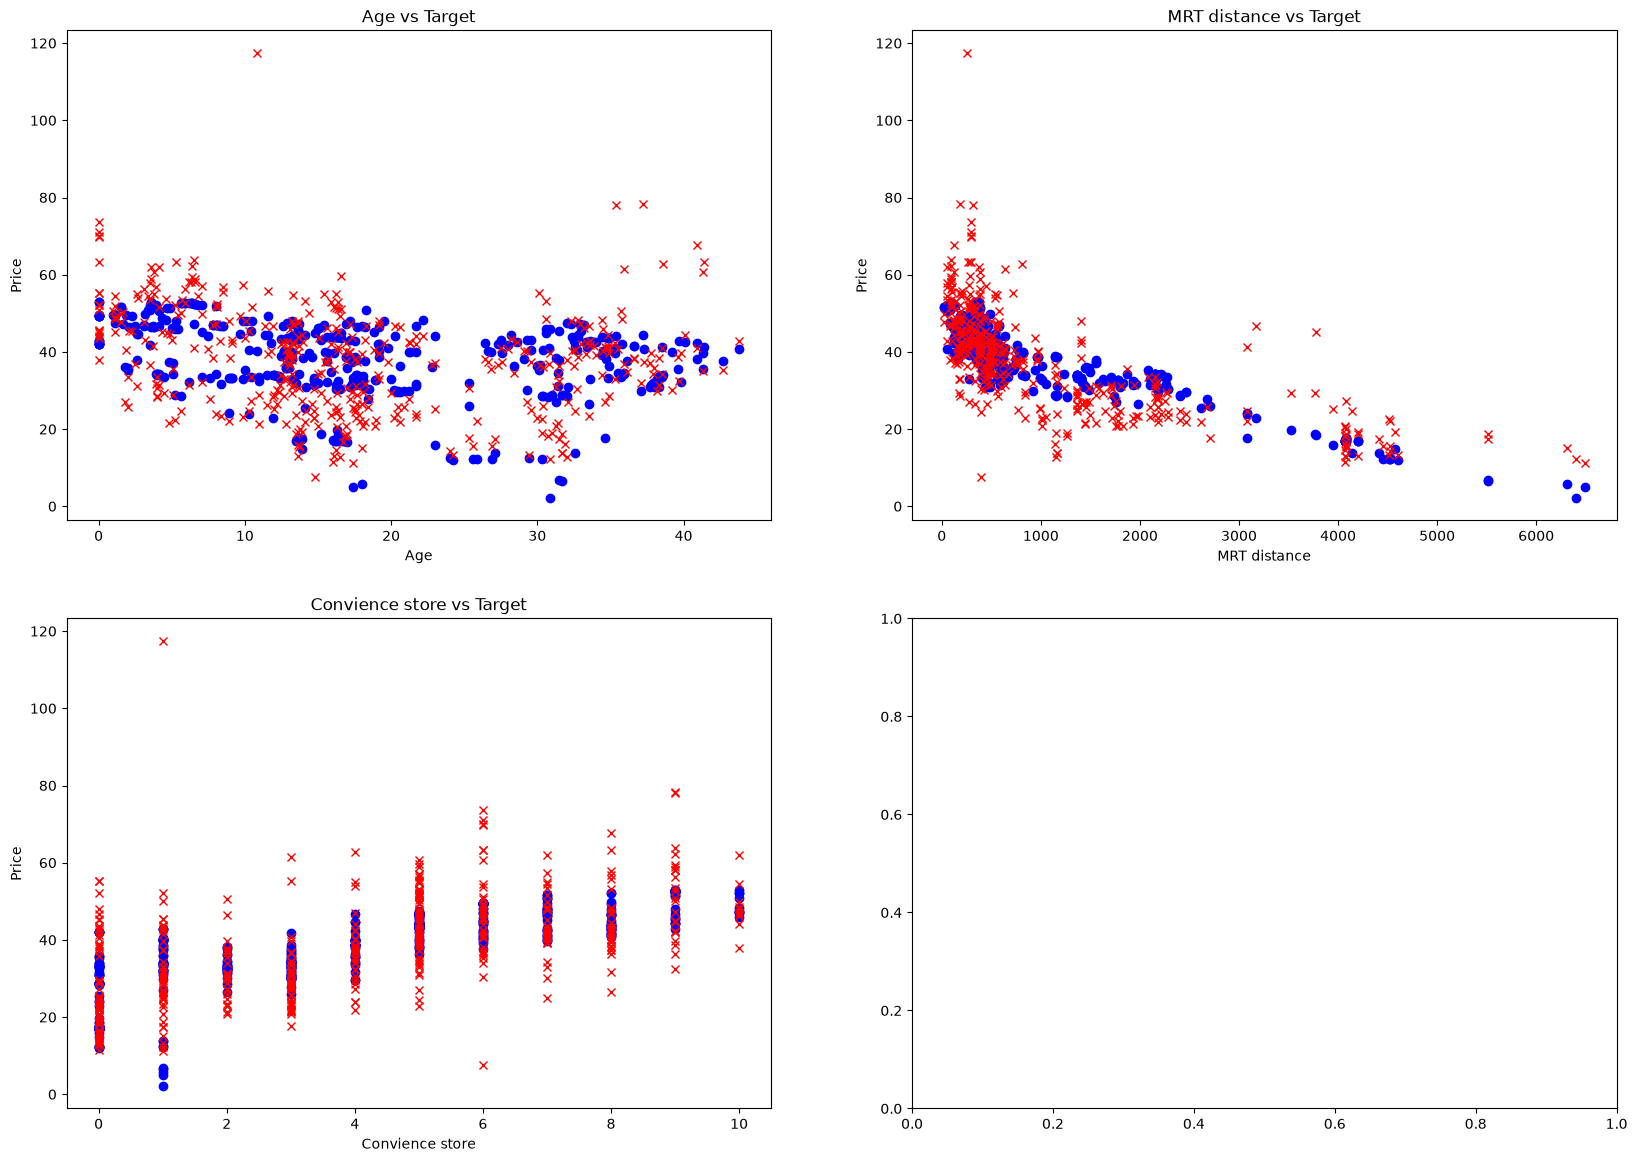

In [317]:
fig , ax = plt.subplots(2, 2, figsize=(20, 14))
yhat = compute_yhat(x_train, w , b)
x_train = data[:, 1:4]
ax[0,0].plot(x_train[:,0], yhat, 'bo')
ax[0,0].plot(x_train[:,0], y_train, 'rx')
ax[0,0].set_title('Age vs Target')
ax[0,0].set_xlabel('Age')
ax[0,0].set_ylabel('Price')
ax[0,1].plot(x_train[:,1], yhat, 'bo')
ax[0,1].plot(x_train[:,1], y_train, 'rx')
ax[0,1].set_title('MRT distance vs Target')
ax[0,1].set_xlabel('MRT distance')
ax[0,1].set_ylabel('Price')
ax[1,0].plot(x_train[:,2], yhat, 'bo')
ax[1,0].plot(x_train[:,2], y_train, 'rx')
ax[1,0].set_title('Convience store vs Target')
ax[1,0].set_xlabel('Convience store')
ax[1,0].set_ylabel('Price')
plt.show()